In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA e bounds
- salvataggio fit

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_1/FORS2.2022-01-07T06_54_16.725/UGC-5823_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_1/FORS2.2022-01-07T06_54_16.725/UGC-5823_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     377   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        58   (2094, 964)   float32   


In [4]:
image_cut = image[48:168, 0:1890]
image_error_cut = image_error[48:168, 0:1890]

Text(0.5, 0, 'wavelength')

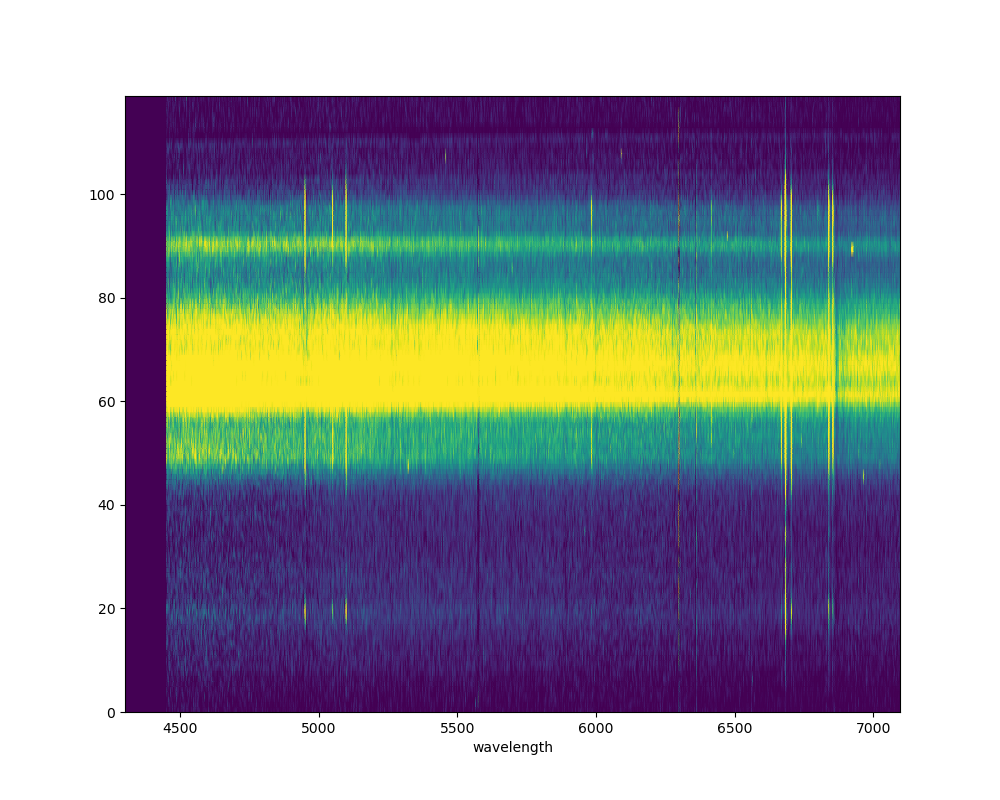

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [6]:
z = 0.0188
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)
seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_1/FORS2.2022-01-07T06_54_16.725/PSF/Real_seeing_UGC5823_1.txt")
sigmas = seeing / 2.35
n_component = 7
print(sigmas)

[1.00123906 1.12126193 0.99945796 0.98766521 1.11810286 1.01319149]


In [7]:
l_HA

6686.3844

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_1/FORS2.2022-01-07T06_54_16.725/UGC-5823_1_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     377   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        58   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

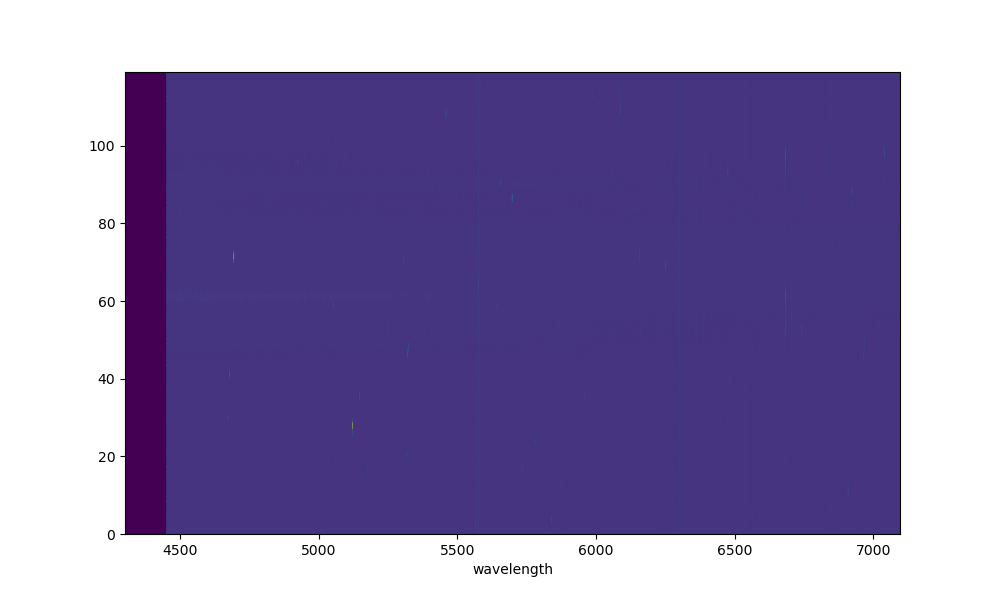

In [8]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_1/FORS2.2022-01-07T06_54_16.725/UGC-5823_1_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[48:168, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

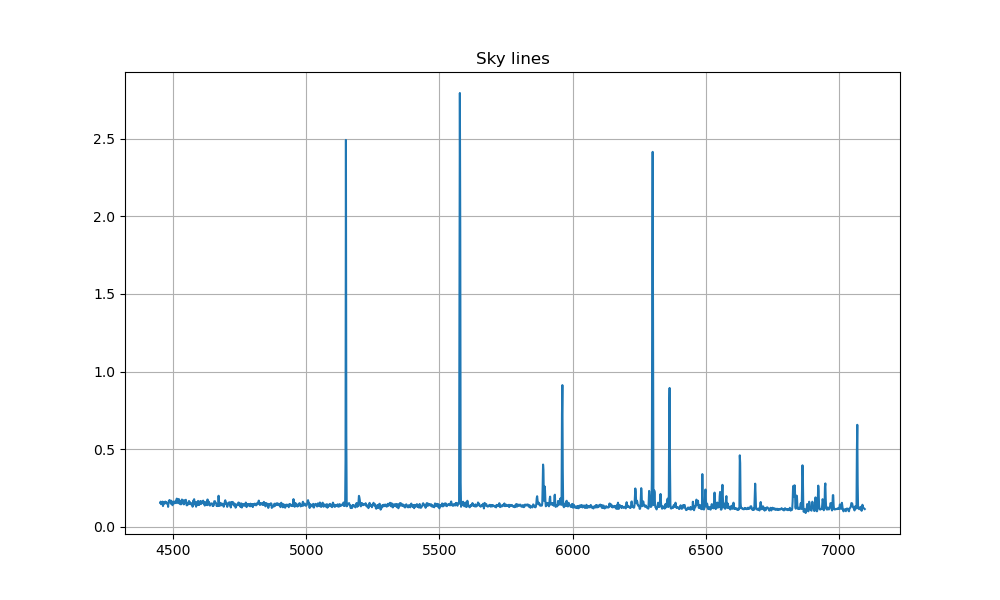

In [9]:
mask_sky = (y > 30)*(y < 40)
mask_wv = wv > 4451
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

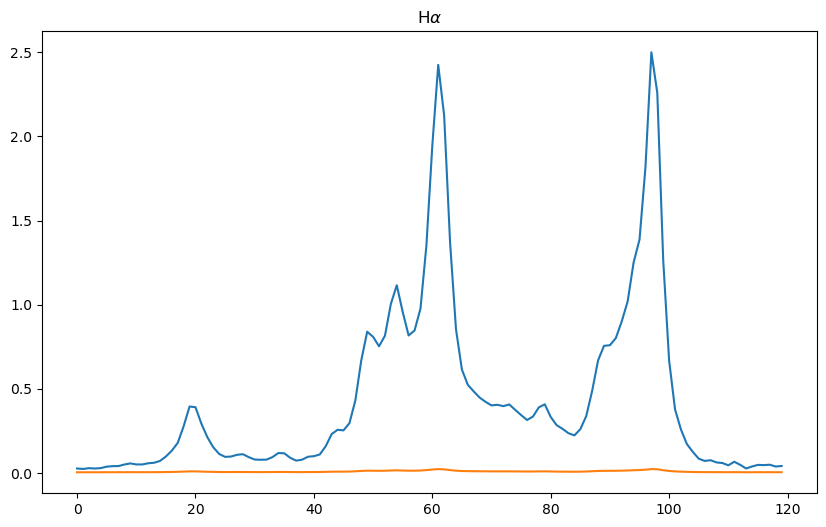

In [9]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_1/FORS2.2022-01-07T06_54_16.725/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [7]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20])+ 
        sersic_1d(x_hr, *params[20:24]) +
        sersic_1d(x_hr, *params[24:28])        
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 2.7)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 2.7)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
    (0, 100),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (18, 22),   # x_0: posizione da 0 a 100

    (0, 20),
    (0, 50),
    (0.1, 10),
    (48, 50),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (52, 54),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (59, 62),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (78, 79),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (88, 90),
    
    (0, 20),
    (0, 50),
    (0.1, 10),
    (95, 99)
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [37]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 2372949.7825103104
differential_evolution step 2: f(x)= 301667.59397314437
differential_evolution step 3: f(x)= 294331.79081850394
differential_evolution step 4: f(x)= 294331.79081850394
differential_evolution step 5: f(x)= 294331.79081850394
differential_evolution step 6: f(x)= 294331.79081850394
differential_evolution step 7: f(x)= 294331.79081850394
differential_evolution step 8: f(x)= 104546.0475458914
differential_evolution step 9: f(x)= 104546.0475458914
differential_evolution step 10: f(x)= 104546.0475458914
differential_evolution step 11: f(x)= 104546.0475458914
differential_evolution step 12: f(x)= 104546.0475458914
differential_evolution step 13: f(x)= 64745.801912235496
differential_evolution step 14: f(x)= 25535.384327469656
differential_evolution step 15: f(x)= 25535.384327469656
differential_evolution step 16: f(x)= 25535.384327469656
differential_evolution step 17: f(x)= 25535.384327469656
differential_evolution step 18: f(x)= 25535.3

Sérsic 1: I_e=0.0456, r_e=7.0723, n=1.4831, x_0=19.5808
Sérsic 2: I_e=0.0408, r_e=9.9667, n=1.9101, x_0=49.0587
Sérsic 3: I_e=0.1943, r_e=2.4218, n=0.9772, x_0=53.8043
Sérsic 4: I_e=0.0495, r_e=24.3325, n=2.7178, x_0=61.0623
Sérsic 5: I_e=0.0728, r_e=10.2648, n=0.8879, x_0=78.0000
Sérsic 6: I_e=0.5116, r_e=3.2919, n=0.1177, x_0=90.0000
Sérsic 7: I_e=0.4792, r_e=3.4701, n=1.2634, x_0=97.0696


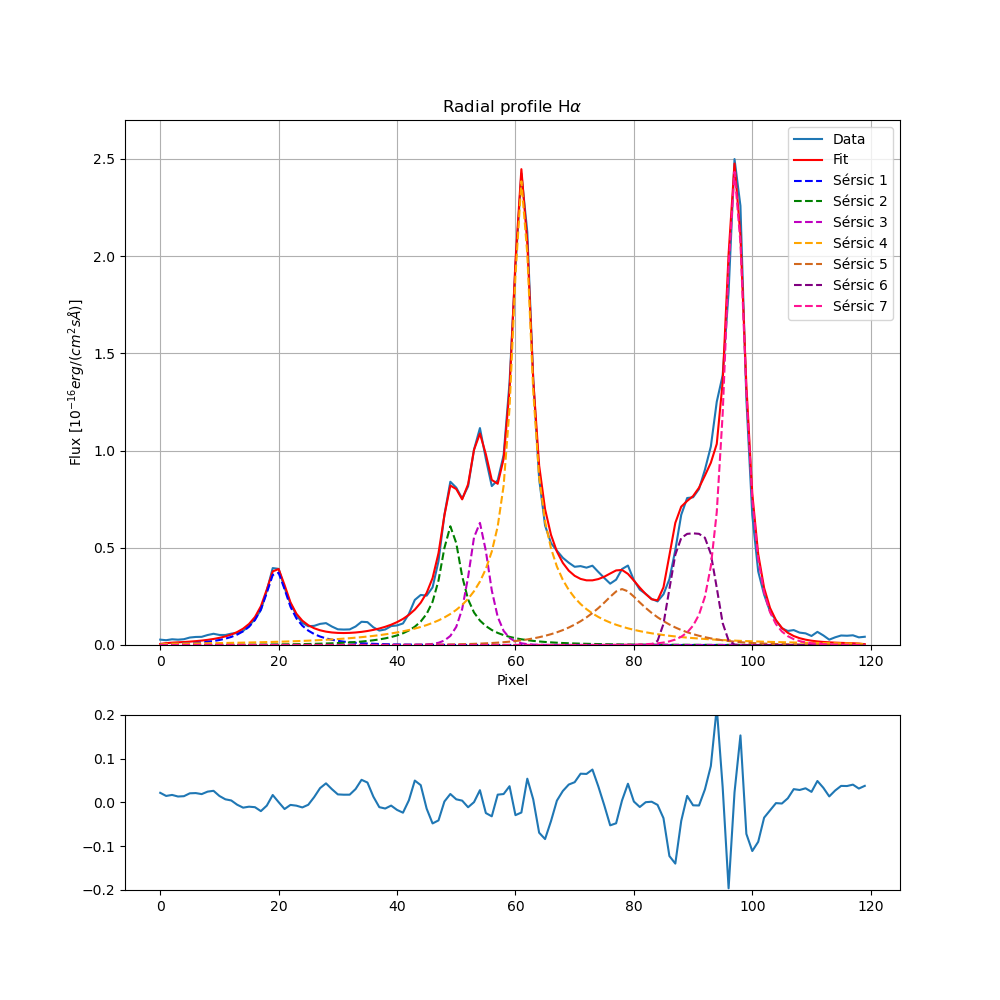

In [38]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [39]:
print(result.x)

[4.56227153e-02 7.07228527e+00 1.48305798e+00 1.95808034e+01
 4.08004417e-02 9.96672194e+00 1.91012211e+00 4.90587263e+01
 1.94258166e-01 2.42177747e+00 9.77165237e-01 5.38042763e+01
 4.94510106e-02 2.43325077e+01 2.71780740e+00 6.10622656e+01
 7.28401823e-02 1.02647821e+01 8.87872689e-01 7.80000000e+01
 5.11629508e-01 3.29185121e+00 1.17729248e-01 9.00000000e+01
 4.79205888e-01 3.47008237e+00 1.26337497e+00 9.70696162e+01]


In [40]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA, bounds = bounds_list)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0207, r_e=12.5939, n=2.0228, x_0=19.5789
Sérsic 2: I_e=0.0258, r_e=13.0095, n=2.2655, x_0=49.1714
Sérsic 3: I_e=0.1475, r_e=2.7052, n=1.2191, x_0=53.7625
Sérsic 4: I_e=0.0400, r_e=27.8285, n=2.8711, x_0=61.0028
Sérsic 5: I_e=0.0694, r_e=12.9484, n=0.8799, x_0=78.0000
Sérsic 6: I_e=0.4900, r_e=2.9453, n=0.1132, x_0=90.0000
Sérsic 7: I_e=0.5611, r_e=3.2117, n=1.1061, x_0=96.8937
[3.10675051e-02 1.69288710e+01 1.04090827e+00 1.67062874e-01
 6.23659906e-02 2.88959669e+01 1.65919012e+00 1.97527604e-01
 2.35095776e-01 2.98404030e+00 1.19328167e+00 1.69483632e-01
 9.33186234e-02 5.76735003e+01 1.81022174e+00 8.13173821e-04
 5.36813055e-02 1.86953063e+01 5.72115419e-01 7.76520354e-01
 1.28630860e-01 1.28424630e+00 1.49226635e-01 2.25152642e-01
 1.25764373e-01 5.14727496e-01 1.83835288e-01 7.53243166e-02]
1.174946367512451


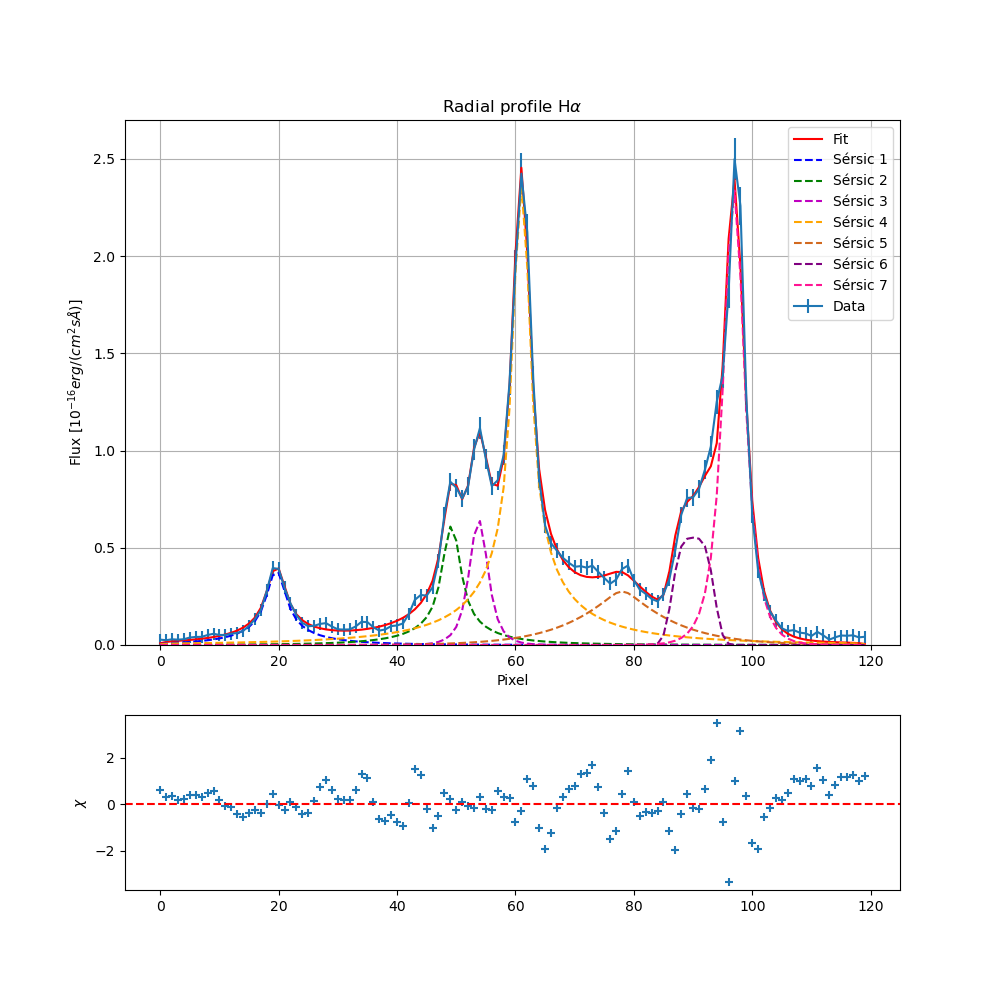

In [41]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [61]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.2, x_0_HA[0]+1.2),   # x_0: circa la posizione di Halpha

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.2, x_0_HA[1]+1.2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.2, x_0_HA[2]+1.2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.2, x_0_HA[3]+1.2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-1.2, x_0_HA[4]+1.2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[5]-1.2, x_0_HA[5]+1.2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[6]-1.2, x_0_HA[6]+1.2),
]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

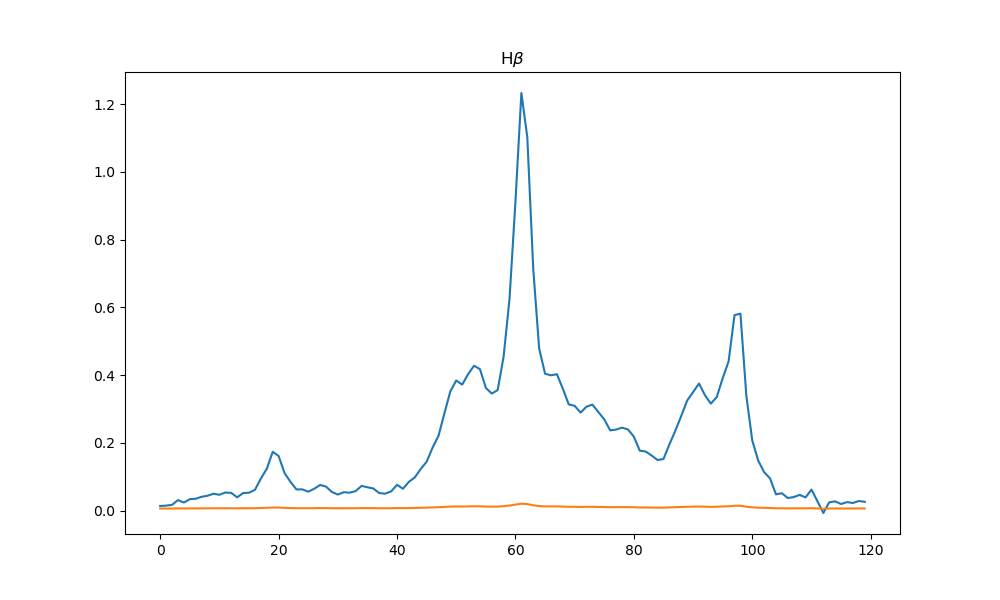

In [64]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))

real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[0])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 120, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [65]:
# Bounds:
bounds = [
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.2, x_0_HA[0]+1.2),   # x_0: circa la posizione di Halpha

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.2, x_0_HA[1]+1.2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1, x_0_HA[2]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.2, x_0_HA[3]+1.2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-1, x_0_HA[4]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[5]-1.2, x_0_HA[5]+1.2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[6]-1.2, x_0_HA[6]+1.2),
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 445348.01487273304
differential_evolution step 2: f(x)= 303725.9758831032
differential_evolution step 3: f(x)= 189527.38746561846
differential_evolution step 4: f(x)= 189527.38746561846
differential_evolution step 5: f(x)= 189527.38746561846
differential_evolution step 6: f(x)= 174172.78953411468
differential_evolution step 7: f(x)= 174172.78953411468
differential_evolution step 8: f(x)= 174172.78953411468
differential_evolution step 9: f(x)= 170676.05750183584
differential_evolution step 10: f(x)= 156503.4639532282
differential_evolution step 11: f(x)= 156503.4639532282
differential_evolution step 12: f(x)= 156503.4639532282
differential_evolution step 13: f(x)= 156503.4639532282
differential_evolution step 14: f(x)= 138413.464304646
differential_evolution step 15: f(x)= 138413.464304646
differential_evolution step 16: f(x)= 138413.464304646
differential_evolution step 17: f(x)= 138413.464304646
differential_evolution step 18: f(x)= 126483.23279333

Sérsic 1: I_e=0.0074, r_e=36.0862, n=1.8002, x_0=19.1995
Sérsic 2: I_e=0.1249, r_e=3.4068, n=0.5524, x_0=50.2804
Sérsic 3: I_e=0.2839, r_e=0.3042, n=0.2061, x_0=53.9860
Sérsic 4: I_e=0.0257, r_e=18.7778, n=2.7258, x_0=61.1813
Sérsic 5: I_e=0.0919, r_e=20.7631, n=0.5590, x_0=77.0980
Sérsic 6: I_e=0.0245, r_e=4.4853, n=1.8907, x_0=90.6883
Sérsic 7: I_e=0.2168, r_e=2.0357, n=0.6736, x_0=97.1851


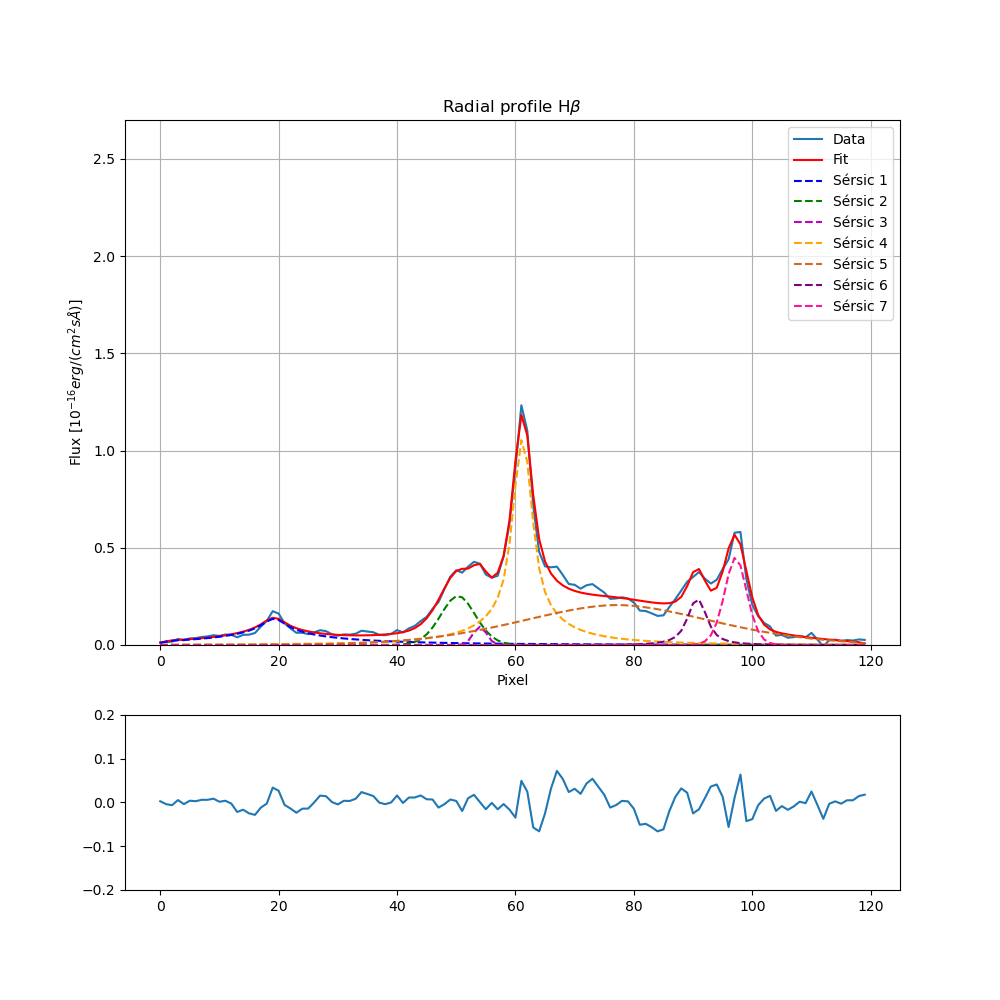

In [66]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [67]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB, bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0074, r_e=36.0862, n=1.8003, x_0=19.1995
Sérsic 2: I_e=0.1253, r_e=3.4071, n=0.5524, x_0=50.2804
Sérsic 3: I_e=0.2841, r_e=0.3047, n=0.2061, x_0=53.9860
Sérsic 4: I_e=0.0256, r_e=18.7778, n=2.7254, x_0=61.1813
Sérsic 5: I_e=0.0919, r_e=20.7630, n=0.5590, x_0=77.0980
Sérsic 6: I_e=0.0246, r_e=4.4853, n=1.8906, x_0=90.6884
Sérsic 7: I_e=0.2167, r_e=2.0357, n=0.6738, x_0=97.1850
[1.34520392e-02 6.86698466e+01 1.17189733e+00 5.80156296e-01
 8.16466940e-02 8.84550769e-01 4.22479966e-01 1.59675750e+00
 2.99631810e+02 1.93782398e+02 1.41097277e+03 6.72174988e-01
 1.62832062e-01 9.94214714e+01 5.22797263e+00 3.26476449e-03
 4.66487167e-02 8.78524344e+00 2.49956912e-01 1.04628413e+01
 1.56117749e-01 2.29266213e+01 4.69386357e+00 2.27805946e-01
 1.02995376e-01 5.04955991e-01 3.63780447e-01 1.22799289e-01]
0.43068981072479706


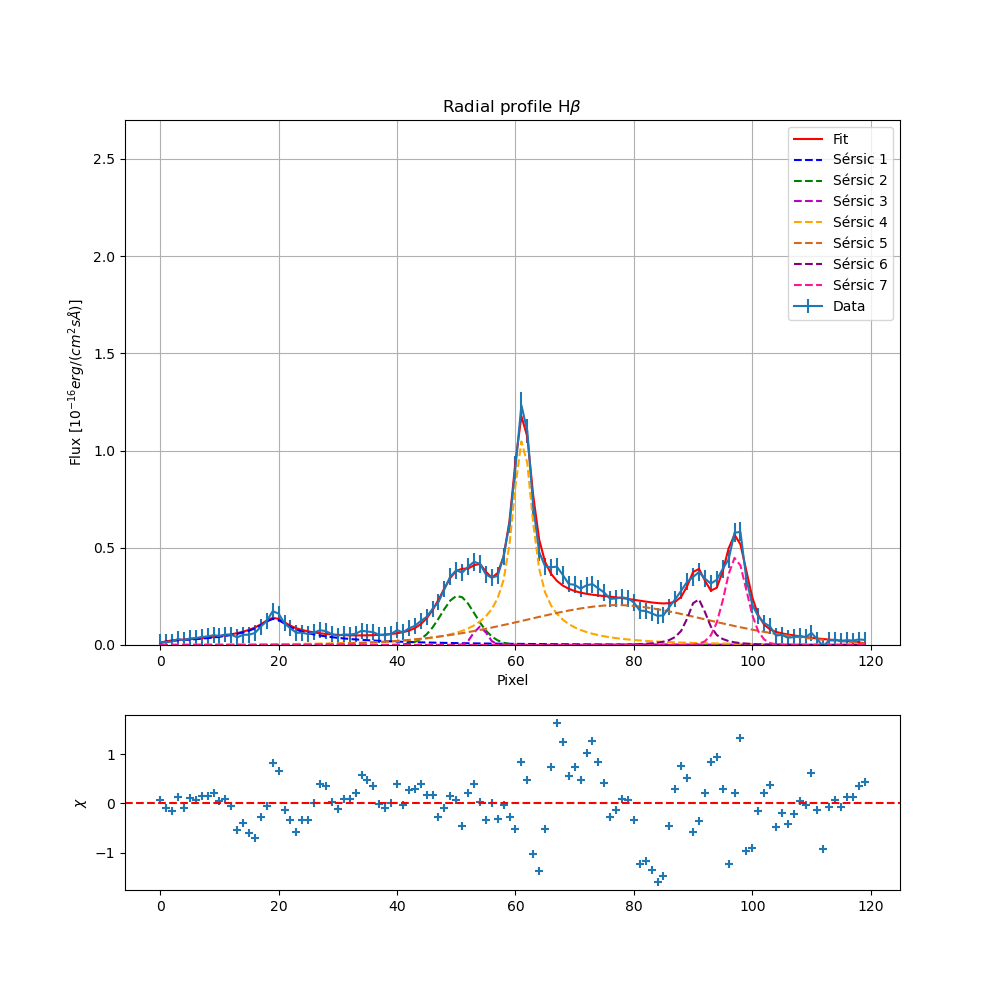

In [68]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

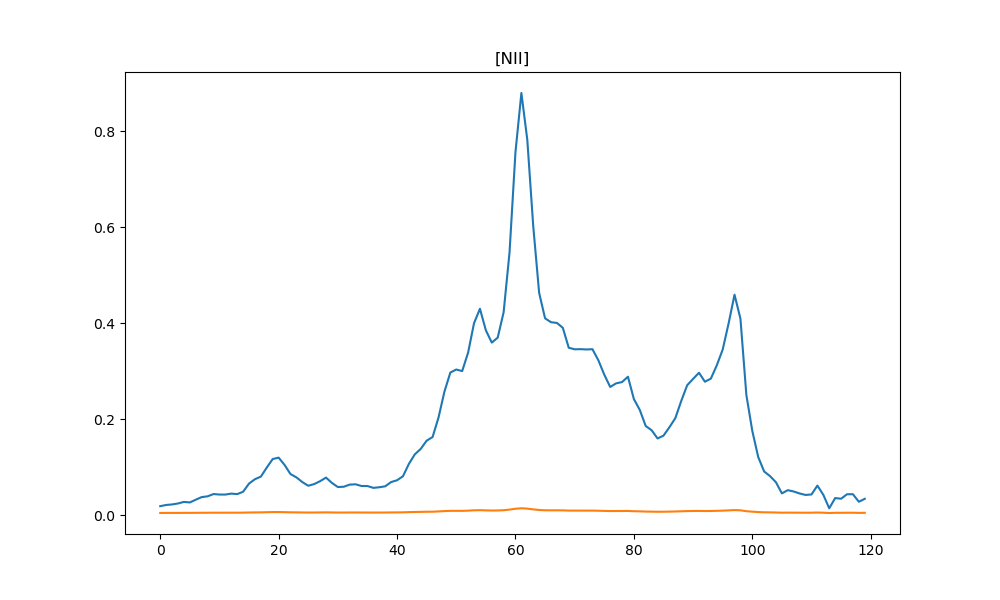

In [49]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))

real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [50]:
# Bounds:

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 362291.87326085946
differential_evolution step 2: f(x)= 362291.87326085946
differential_evolution step 3: f(x)= 362291.87326085946
differential_evolution step 4: f(x)= 218691.39917825142
differential_evolution step 5: f(x)= 218691.39917825142
differential_evolution step 6: f(x)= 218691.39917825142
differential_evolution step 7: f(x)= 210454.54137236273
differential_evolution step 8: f(x)= 210454.54137236273
differential_evolution step 9: f(x)= 144847.19315033342
differential_evolution step 10: f(x)= 144847.19315033342
differential_evolution step 11: f(x)= 144847.19315033342
differential_evolution step 12: f(x)= 98456.91485827736
differential_evolution step 13: f(x)= 98456.91485827736
differential_evolution step 14: f(x)= 98456.91485827736
differential_evolution step 15: f(x)= 33597.74705124441
differential_evolution step 16: f(x)= 33597.74705124441
differential_evolution step 17: f(x)= 33597.74705124441
differential_evolution step 18: f(x)= 29713.57

Sérsic 1: I_e=0.0067, r_e=34.6148, n=1.6659, x_0=19.0234
Sérsic 2: I_e=0.0269, r_e=5.2054, n=1.2068, x_0=49.0071
Sérsic 3: I_e=0.0313, r_e=1.8898, n=1.6905, x_0=53.4546
Sérsic 4: I_e=0.0410, r_e=17.8418, n=1.8936, x_0=61.0623
Sérsic 5: I_e=0.0630, r_e=25.3497, n=0.8404, x_0=76.8000
Sérsic 6: I_e=0.1202, r_e=2.3514, n=0.1778, x_0=91.0322
Sérsic 7: I_e=0.1199, r_e=2.4013, n=0.9132, x_0=96.9636


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_4404\3366555606.py:69: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])


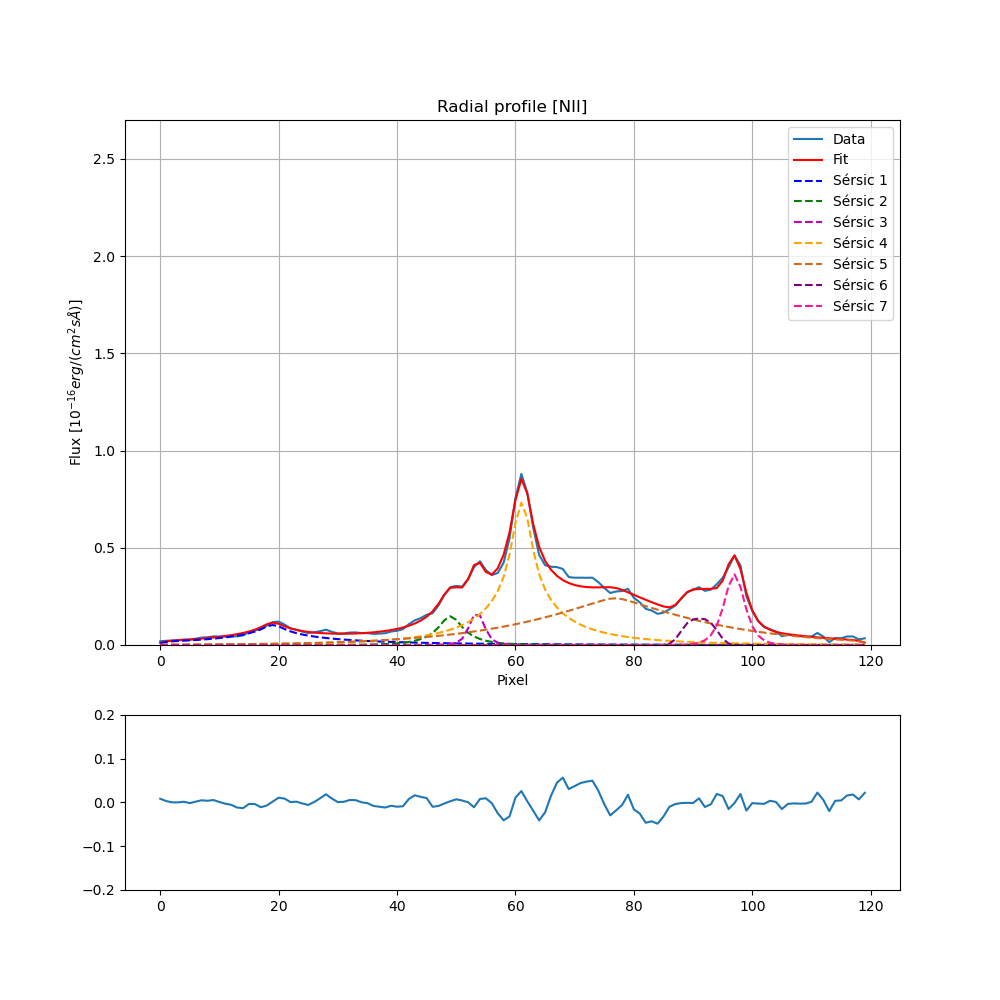

In [51]:
# Plots:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [52]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0057, r_e=34.6793, n=1.7788, x_0=19.4212
Sérsic 2: I_e=0.0287, r_e=4.6061, n=1.1724, x_0=49.2140
Sérsic 3: I_e=0.0274, r_e=1.5411, n=2.0445, x_0=53.5442
Sérsic 4: I_e=0.0365, r_e=22.3326, n=1.9387, x_0=61.1218
Sérsic 5: I_e=0.0529, r_e=25.8954, n=0.9017, x_0=76.8000
Sérsic 6: I_e=0.1273, r_e=2.5934, n=0.1509, x_0=91.1149
Sérsic 7: I_e=0.1166, r_e=2.4373, n=0.9472, x_0=96.9967
[8.42740007e-03 4.93664056e+01 9.41716124e-01 4.89285828e-01
 3.51077400e-02 4.83206852e+00 9.04834378e-01 4.05232479e-01
 2.87294690e-01 9.23766554e+00 9.80452044e+00 1.97094034e-01
 2.46369649e-02 1.65042822e+01 4.34639370e-01 9.46841577e-02
 1.50541333e-02 3.96156869e+00 1.30791800e-01 8.52598053e-01
 1.30935589e-02 7.65609917e-01 2.41475810e-01 5.23494554e-01
 5.89897982e-02 6.49899103e-01 3.98221541e-01 2.13391091e-01]
0.3329025593301544


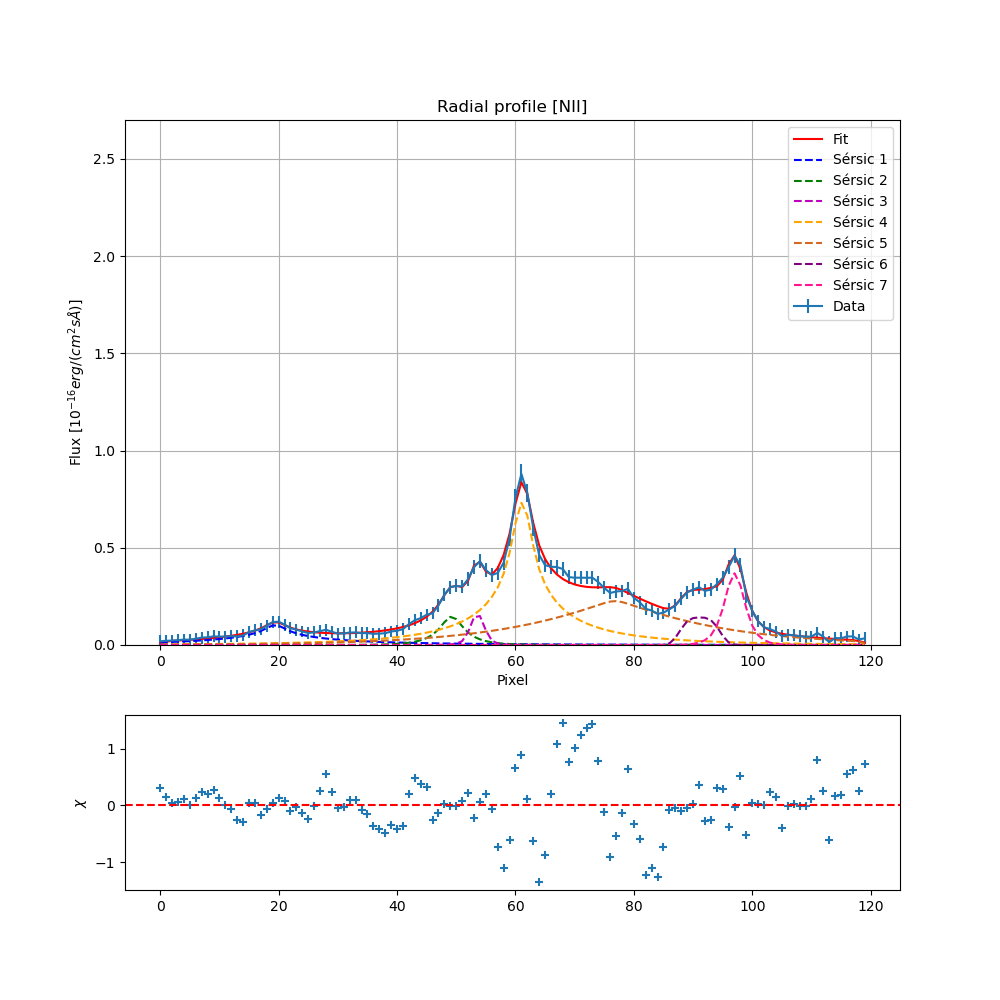

In [53]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

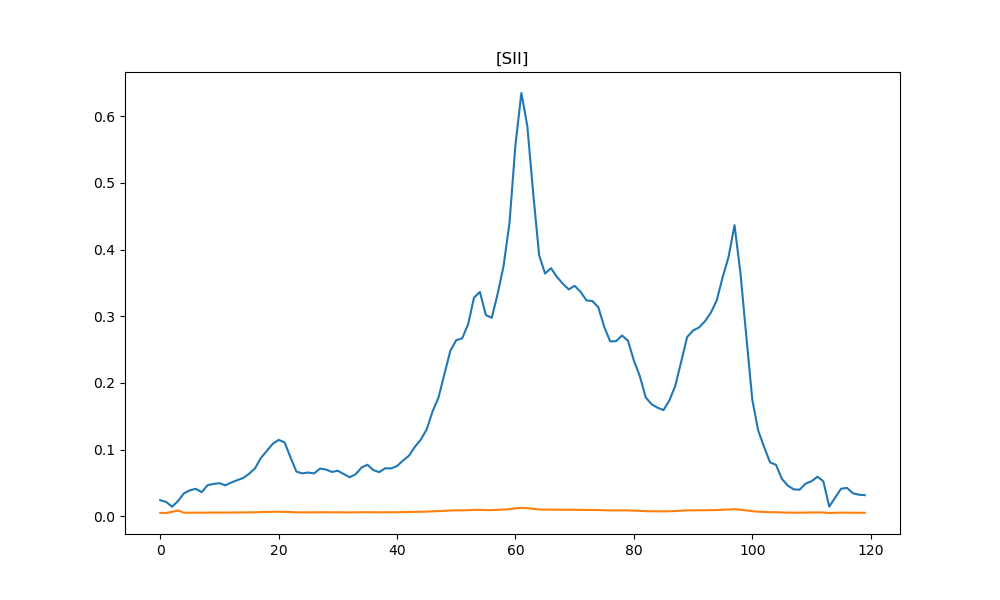

In [55]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 120, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))

real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[3])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [56]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 935474.4958886302
differential_evolution step 2: f(x)= 935474.4958886302
differential_evolution step 3: f(x)= 364438.0781912379
differential_evolution step 4: f(x)= 364438.0781912379
differential_evolution step 5: f(x)= 364438.0781912379
differential_evolution step 6: f(x)= 364438.0781912379
differential_evolution step 7: f(x)= 364438.0781912379
differential_evolution step 8: f(x)= 311758.00973259844
differential_evolution step 9: f(x)= 111042.3681386227
differential_evolution step 10: f(x)= 111042.3681386227
differential_evolution step 11: f(x)= 111042.3681386227
differential_evolution step 12: f(x)= 111042.3681386227
differential_evolution step 13: f(x)= 111042.3681386227
differential_evolution step 14: f(x)= 111042.3681386227
differential_evolution step 15: f(x)= 111042.3681386227
differential_evolution step 16: f(x)= 111042.3681386227
differential_evolution step 17: f(x)= 111042.3681386227
differential_evolution step 18: f(x)= 111042.3681386227


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_4404\3366555606.py:9: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=0.0164, r_e=9.5721, n=0.9653, x_0=18.8551
Sérsic 2: I_e=0.0393, r_e=2.4542, n=0.7650, x_0=49.3161
Sérsic 3: I_e=0.0414, r_e=1.2213, n=0.9566, x_0=53.2930
Sérsic 4: I_e=0.0239, r_e=49.3587, n=1.9390, x_0=61.0834
Sérsic 5: I_e=0.0757, r_e=11.1211, n=0.5214, x_0=76.8025
Sérsic 6: I_e=1.2871, r_e=0.0472, n=0.6959, x_0=89.5291
Sérsic 7: I_e=0.1349, r_e=4.4029, n=0.6751, x_0=96.1019
Chi quadro minimo: 0.036019495097376585
False


Sérsic 1: I_e=0.0164, r_e=9.5721, n=0.9653, x_0=18.8551
Sérsic 2: I_e=0.0393, r_e=2.4542, n=0.7650, x_0=49.3161
Sérsic 3: I_e=0.0414, r_e=1.2213, n=0.9566, x_0=53.2930
Sérsic 4: I_e=0.0239, r_e=49.3587, n=1.9390, x_0=61.0834
Sérsic 5: I_e=0.0757, r_e=11.1211, n=0.5214, x_0=76.8025
Sérsic 6: I_e=1.2871, r_e=0.0472, n=0.6959, x_0=89.5291
Sérsic 7: I_e=0.1349, r_e=4.4029, n=0.6751, x_0=96.1019


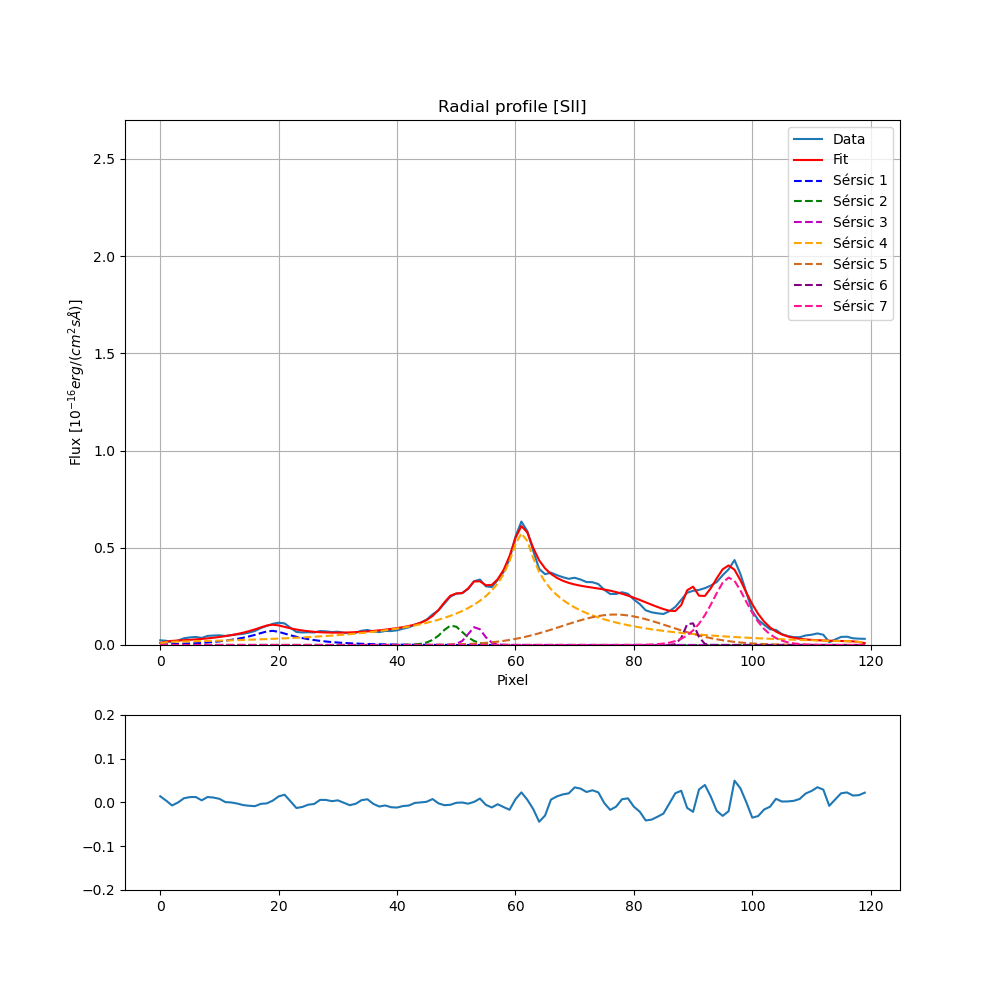

In [57]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [62]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII, bounds = bounds_list)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0120, r_e=10.9539, n=1.2062, x_0=19.0891
Sérsic 2: I_e=0.0483, r_e=2.3054, n=0.5720, x_0=49.5398
Sérsic 3: I_e=0.0655, r_e=0.6140, n=1.0272, x_0=53.4078
Sérsic 4: I_e=0.0246, r_e=49.8577, n=1.9156, x_0=61.0920
Sérsic 5: I_e=0.0762, r_e=10.5707, n=0.4962, x_0=76.8003
Sérsic 6: I_e=1.2477, r_e=0.0473, n=0.6764, x_0=89.4672
Sérsic 7: I_e=0.1425, r_e=4.3056, n=0.6417, x_0=95.9710
[1.14273716e-02 8.98275594e+00 6.43477681e-01 5.40561987e-01
 4.83192051e-02 1.33877225e+00 7.48154413e-01 8.80125740e-01
 1.28382225e+00 3.87330250e+00 2.03931523e+01 4.49349203e-01
 1.26965233e-02 1.86535713e+01 3.63464127e-01 4.11319023e-02
 3.56187602e-02 6.23945043e+00 2.82409553e-01 9.46210592e-01
 2.09748953e+05 2.57096950e+02 2.25279730e+05 5.13719203e+01
 2.25763700e-02 6.11393513e-01 1.03659288e-01 1.93139618e-01]
0.6639942102172788


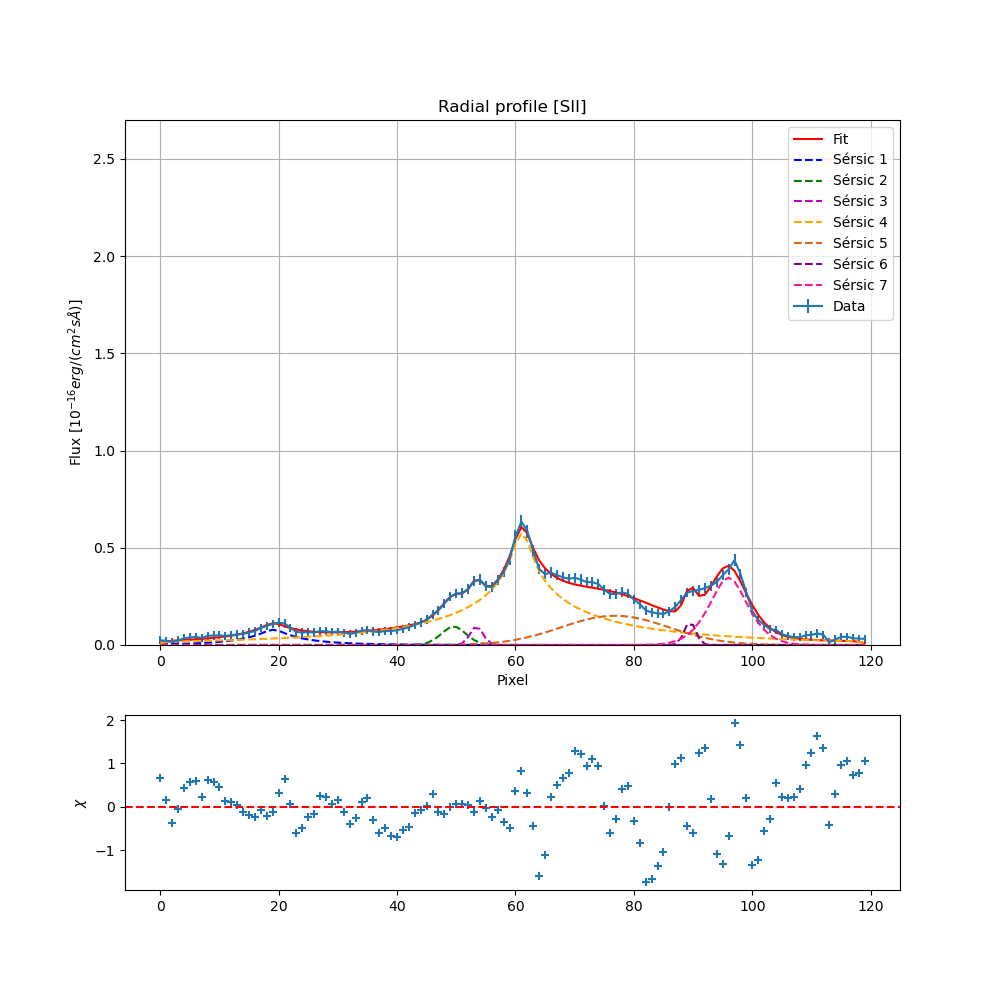

In [63]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

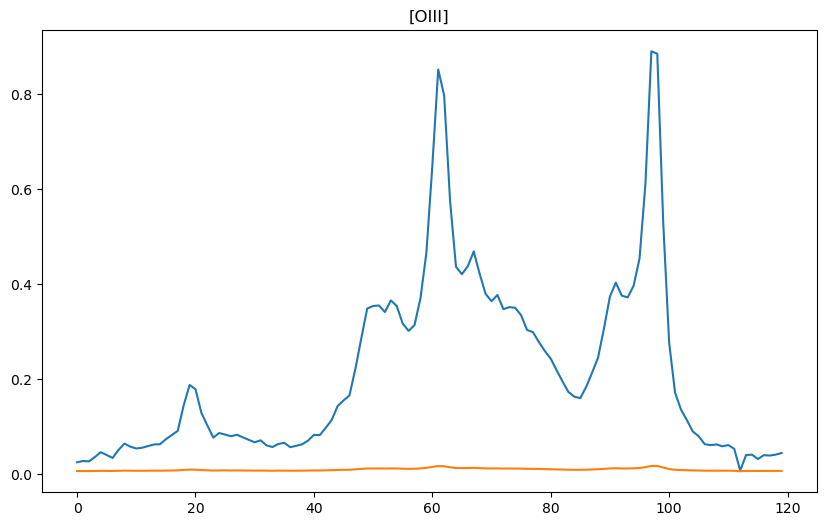

In [10]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))

real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[1])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [17]:
x_0_HA

array([19.5789, 49.1714, 53.7625, 61.0028, 78.    , 90.    , 96.8937])

In [18]:
# Bounds:
fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_1/FORS2.2022-01-07T06_54_16.725/Fit/Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.2, x_0_HA[0]+1.2),   # x_0: circa la posizione di Halpha

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.2, x_0_HA[1]+1.2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1, 54),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.2, x_0_HA[3]+1.2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (77.5, 78.3),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[5]-1.2, x_0_HA[5]+1.2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[6]-1.2, x_0_HA[6]+1.2),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 666805.3381768287
differential_evolution step 2: f(x)= 666805.3381768287
differential_evolution step 3: f(x)= 399219.83559996897
differential_evolution step 4: f(x)= 236789.50425322427
differential_evolution step 5: f(x)= 196265.87156078446
differential_evolution step 6: f(x)= 196265.87156078446
differential_evolution step 7: f(x)= 196265.87156078446
differential_evolution step 8: f(x)= 193804.81433071708
differential_evolution step 9: f(x)= 87311.00513494408
differential_evolution step 10: f(x)= 87311.00513494408
differential_evolution step 11: f(x)= 87311.00513494408
differential_evolution step 12: f(x)= 87311.00513494408
differential_evolution step 13: f(x)= 66688.75399059906
differential_evolution step 14: f(x)= 59770.447146059036
differential_evolution step 15: f(x)= 59770.447146059036
differential_evolution step 16: f(x)= 50918.43710379183
differential_evolution step 17: f(x)= 30465.451590662848
differential_evolution step 18: f(x)= 30465.4515

Sérsic 1: I_e=0.0126, r_e=17.7612, n=1.5541, x_0=19.2157
Sérsic 2: I_e=0.0755, r_e=2.4537, n=0.8429, x_0=49.0454
Sérsic 3: I_e=0.0160, r_e=1.9047, n=2.2117, x_0=52.8582
Sérsic 4: I_e=0.0274, r_e=29.8282, n=2.0861, x_0=61.3990
Sérsic 5: I_e=0.0497, r_e=25.6024, n=0.9410, x_0=77.5541
Sérsic 6: I_e=0.1736, r_e=2.3626, n=0.3263, x_0=91.1386
Sérsic 7: I_e=0.1354, r_e=2.5659, n=1.7072, x_0=97.3784


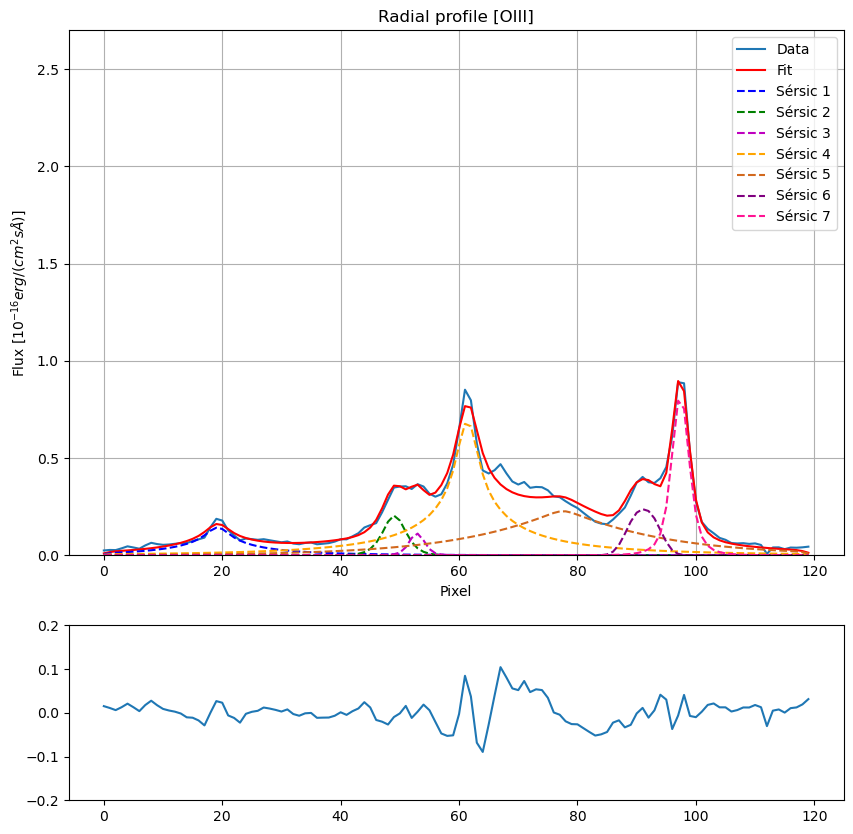

In [19]:
# Plots:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [21]:
x_0_HA

array([19.5789, 49.1714, 53.7625, 61.0028, 78.    , 90.    , 96.8937])

In [24]:
bounds =  [
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.2, x_0_HA[0]+1.2),   # x_0: circa la posizione di Halpha

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.2, x_0_HA[1]+1.2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1, 54),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.2, x_0_HA[3]+1.2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (77.5, 78.3),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[5]-1.2, x_0_HA[5]+1.2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[6]-1.2, x_0_HA[6]+1.2),
]
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0105, r_e=18.8770, n=1.7111, x_0=19.2801
Sérsic 2: I_e=0.0720, r_e=2.3547, n=0.8277, x_0=49.2886
Sérsic 3: I_e=0.0153, r_e=1.2941, n=2.5737, x_0=52.9087
Sérsic 4: I_e=0.0295, r_e=30.9342, n=1.9906, x_0=61.4789
Sérsic 5: I_e=0.0492, r_e=25.3931, n=0.9094, x_0=77.5117
Sérsic 6: I_e=0.2024, r_e=2.1586, n=0.1795, x_0=91.1792
Sérsic 7: I_e=0.1132, r_e=3.0420, n=1.8034, x_0=97.3589
[1.95355505e-02 3.50821457e+01 1.24001621e+00 4.53916032e-01
 9.13313291e-02 1.99685172e+00 1.00819855e+00 5.86983159e-01
 7.38953854e-01 3.22245666e+01 2.88505253e+02 3.48292422e-01
 5.25483770e-02 4.89074264e+01 1.33204323e+00 5.71773836e-02
 2.16548847e-02 1.20761871e+01 2.66028298e-01 1.35670857e+00
 6.16900504e-02 4.72591303e-01 4.05395542e-01 2.98562870e-01
 1.24125872e-01 2.10438935e+00 9.28368845e-01 8.71176609e-02]
0.8170969847907984


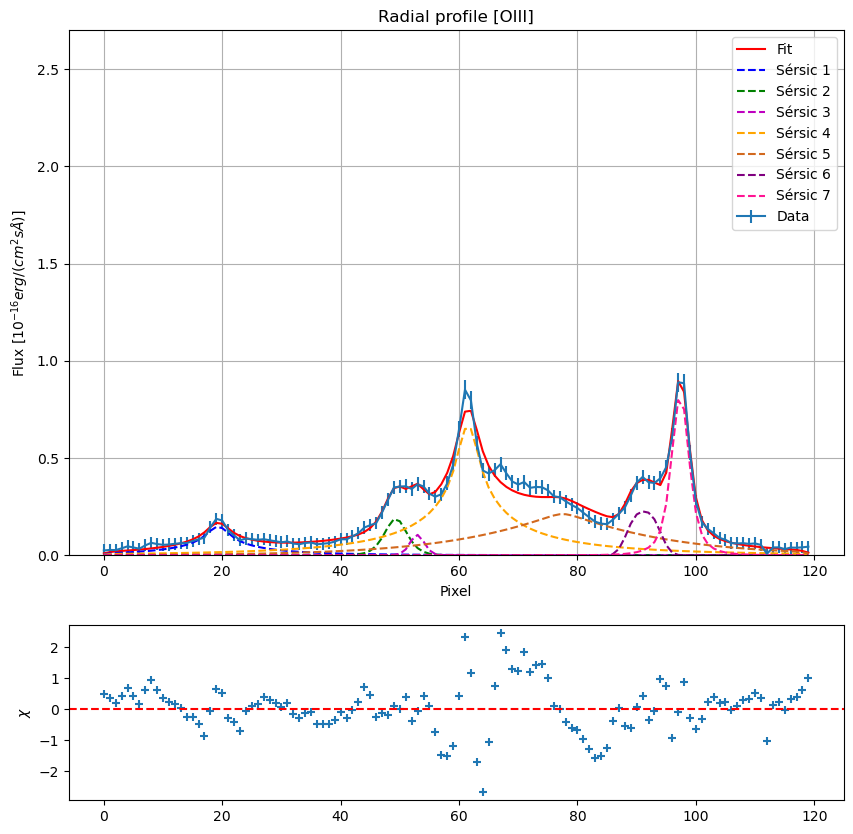

In [25]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [26]:
d1 = {'Name': ['OIII'], 'Chi squared': chi2_OIII,
      'Dof': dof_OIII, 'Chi reduced': chi2_reduced_OIII}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_OIII_curve_fit.csv", index= False)

In [232]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

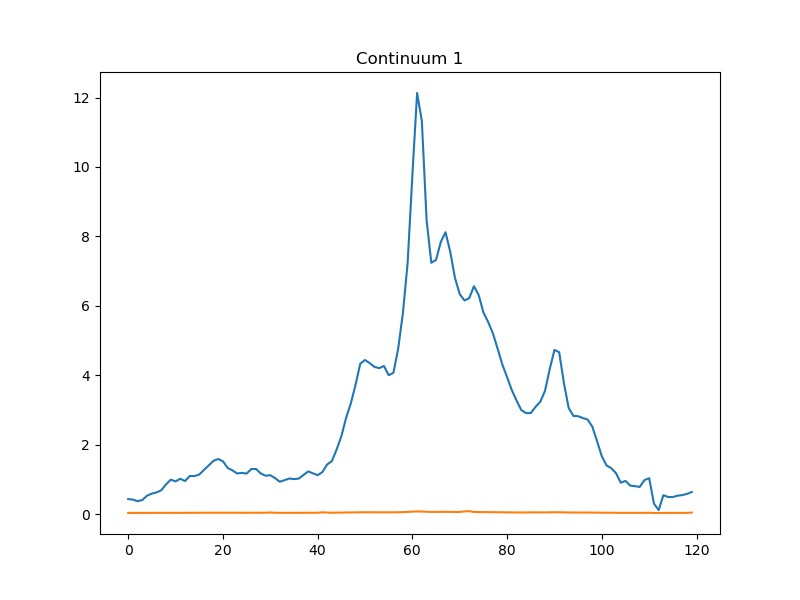

In [79]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))

real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[0])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [80]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 2862274.674194224
differential_evolution step 2: f(x)= 1008086.392385036
differential_evolution step 3: f(x)= 875780.8384343592
differential_evolution step 4: f(x)= 875780.8384343592
differential_evolution step 5: f(x)= 221600.2512729022
differential_evolution step 6: f(x)= 221600.2512729022
differential_evolution step 7: f(x)= 209172.113688862
differential_evolution step 8: f(x)= 152299.5396364734
differential_evolution step 9: f(x)= 152299.5396364734
differential_evolution step 10: f(x)= 123319.36390976381
differential_evolution step 11: f(x)= 123319.36390976381
differential_evolution step 12: f(x)= 65261.426447257545
differential_evolution step 13: f(x)= 65261.426447257545
differential_evolution step 14: f(x)= 65261.426447257545
differential_evolution step 15: f(x)= 65261.426447257545
differential_evolution step 16: f(x)= 65261.426447257545
differential_evolution step 17: f(x)= 65261.426447257545
differential_evolution step 18: f(x)= 65261.426447

In [81]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)    

Sérsic 1: I_e=0.9603, r_e=8.7447, n=0.2518, x_0=18.0000
Sérsic 2: I_e=1.4858, r_e=2.7095, n=0.2938, x_0=49.9088
Sérsic 3: I_e=1.0231, r_e=19.0258, n=0.1096, x_0=54.0000
Sérsic 4: I_e=0.5504, r_e=18.3262, n=1.9411, x_0=61.2111
Sérsic 5: I_e=2.4390, r_e=11.5317, n=0.1000, x_0=78.2953
Sérsic 6: I_e=0.6252, r_e=23.0969, n=0.1033, x_0=89.4003
Sérsic 7: I_e=1.6101, r_e=4.1906, n=0.1449, x_0=95.0000


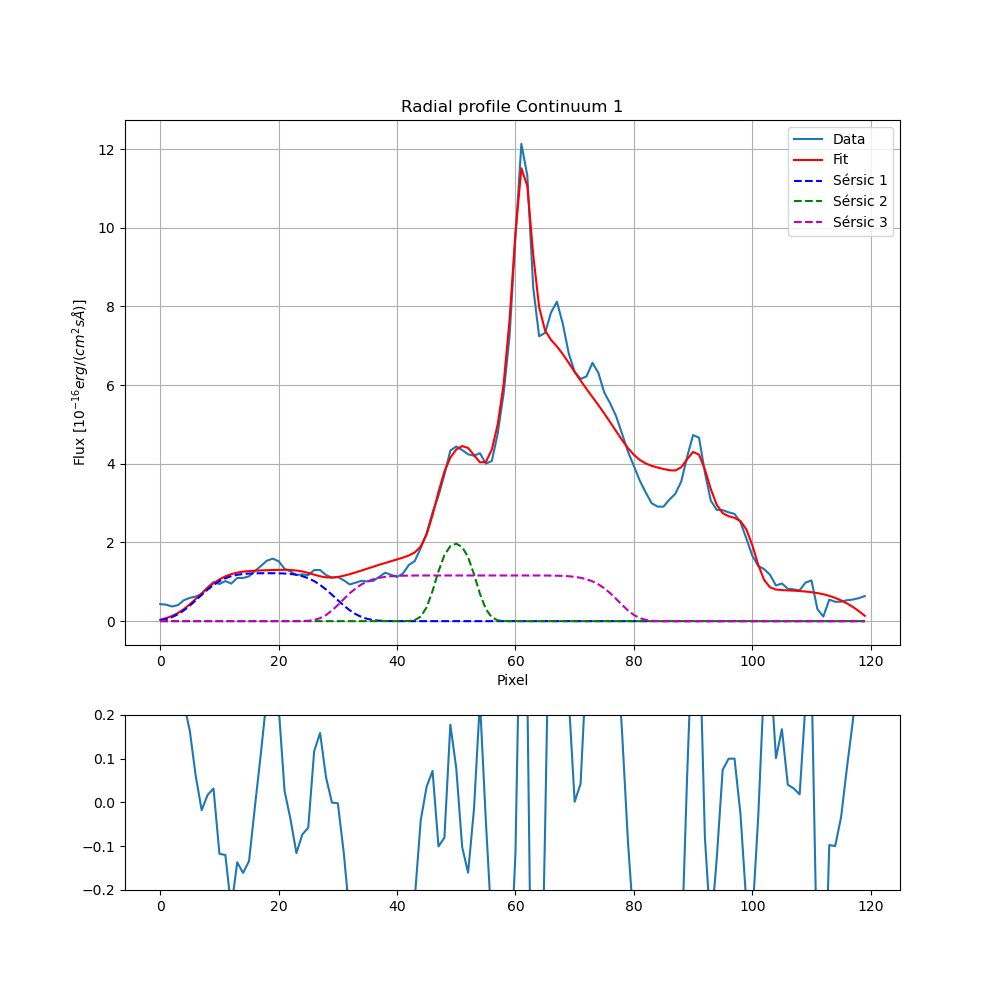

In [82]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [83]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.3587, r_e=18.3569, n=0.8806, x_0=18.0024
Sérsic 2: I_e=1.3054, r_e=2.9092, n=0.4026, x_0=49.1134
Sérsic 3: I_e=0.3746, r_e=22.8922, n=0.1000, x_0=52.3971
Sérsic 4: I_e=1.6031, r_e=12.5915, n=1.0859, x_0=62.0000
Sérsic 5: I_e=1.9390, r_e=11.2417, n=0.1000, x_0=79.0000
Sérsic 6: I_e=0.6018, r_e=22.1768, n=0.2148, x_0=90.0000
Sérsic 7: I_e=1.2951, r_e=4.4775, n=0.3278, x_0=95.0000
[ 0.21970665  8.71053544  0.37126323  1.43877547  0.5114646   0.92027055
  0.33711347  0.69563078  0.63531428 14.33740067  0.17585669  4.5926283
  2.24397421 10.79670842  0.67968903  0.63468358  0.73173416  4.73824223
  0.10897977  1.2693098   0.39134685 28.37682638  0.68599165 44.70687708
  0.30500861  0.77694542  0.18635671  1.08181562]
7.623873248252286


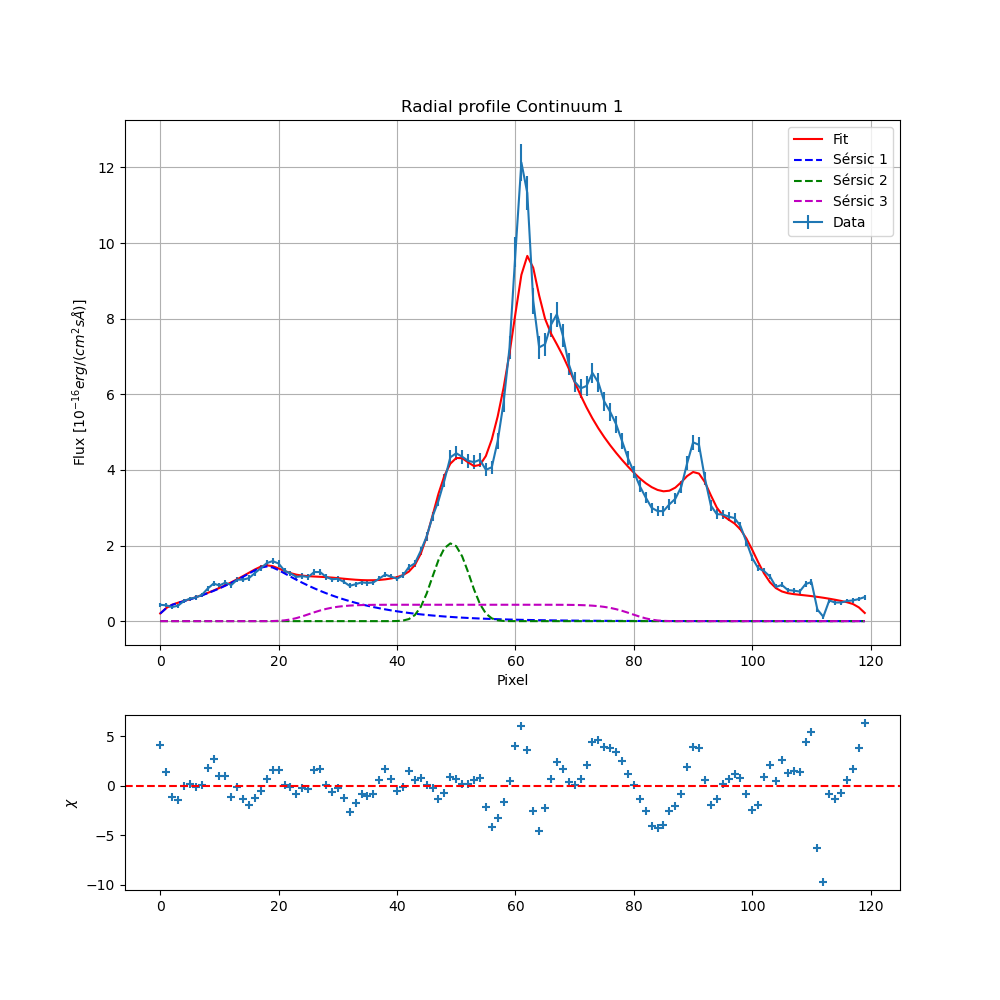

In [84]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

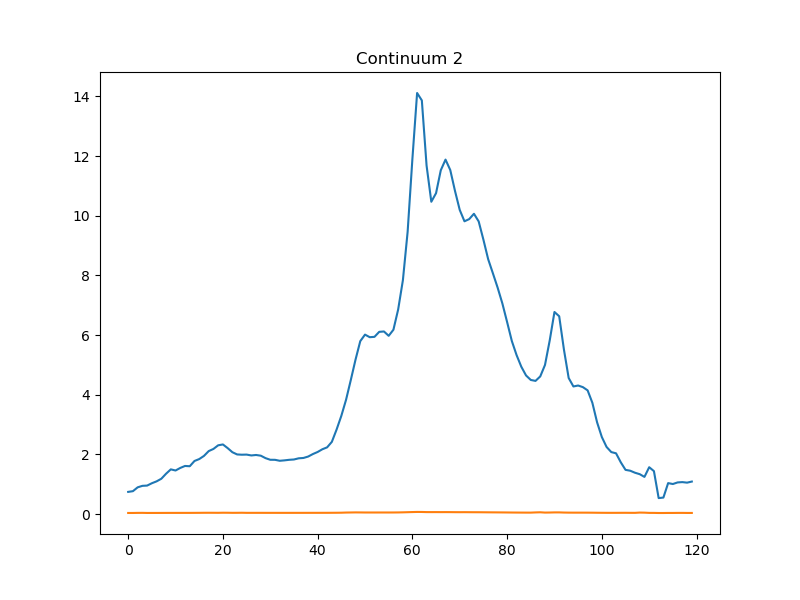

In [85]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))

real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [86]:
# Bounds:
bounds = bounds_HA
seeing_i = 3.174
sigma_i = seeing_i/ 2.35

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigma_i)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 769600.5468542031
differential_evolution step 2: f(x)= 769600.5468542031
differential_evolution step 3: f(x)= 732485.012729222
differential_evolution step 4: f(x)= 719021.9502525073
differential_evolution step 5: f(x)= 176655.57620137086
differential_evolution step 6: f(x)= 176655.57620137086
differential_evolution step 7: f(x)= 176655.57620137086
differential_evolution step 8: f(x)= 176655.57620137086
differential_evolution step 9: f(x)= 176655.57620137086
differential_evolution step 10: f(x)= 163274.89508484013
differential_evolution step 11: f(x)= 163274.89508484013
differential_evolution step 12: f(x)= 163274.89508484013
differential_evolution step 13: f(x)= 144065.29823545733
differential_evolution step 14: f(x)= 98271.61028298113
differential_evolution step 15: f(x)= 98271.61028298113
differential_evolution step 16: f(x)= 98271.61028298113
differential_evolution step 17: f(x)= 83207.04438298337
differential_evolution step 18: f(x)= 50508.62648

Sérsic 1: I_e=1.3823, r_e=9.5387, n=0.3448, x_0=18.0000
Sérsic 2: I_e=1.9384, r_e=2.4765, n=0.1990, x_0=49.5521
Sérsic 3: I_e=1.5413, r_e=20.9181, n=0.1000, x_0=54.0000
Sérsic 4: I_e=2.0995, r_e=11.3268, n=1.0515, x_0=61.8657
Sérsic 5: I_e=3.3523, r_e=10.9703, n=0.1000, x_0=78.9834
Sérsic 6: I_e=1.1424, r_e=24.6645, n=0.1000, x_0=90.0000
Sérsic 7: I_e=2.2288, r_e=4.6458, n=0.1000, x_0=95.0000


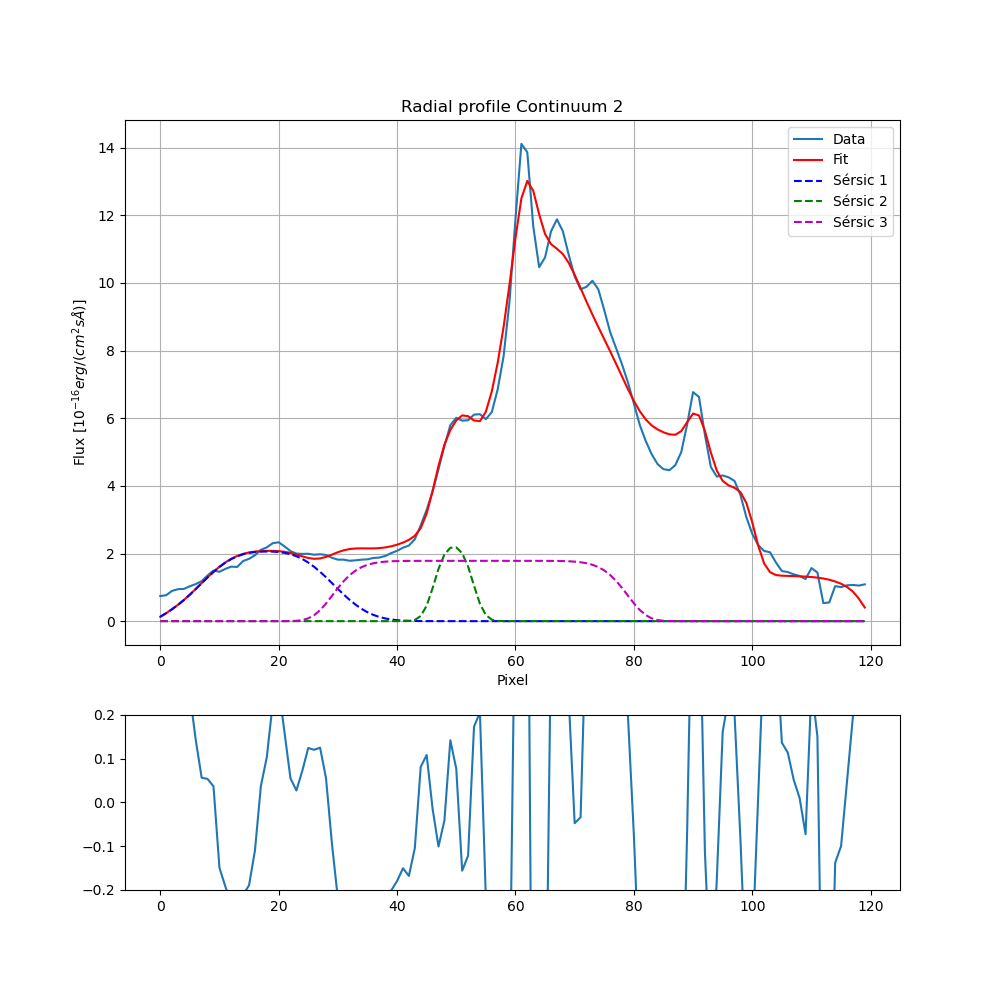

In [87]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigma_i,
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigma_i, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [88]:
bounds = bounds_HA
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigma_i, *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigma_i, x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.2864, r_e=44.5051, n=1.2399, x_0=18.4708
Sérsic 2: I_e=1.5707, r_e=2.3860, n=0.3271, x_0=48.9896
Sérsic 3: I_e=0.5509, r_e=23.6448, n=0.1000, x_0=52.0895
Sérsic 4: I_e=2.7832, r_e=11.9154, n=0.7960, x_0=62.0000
Sérsic 5: I_e=3.0232, r_e=12.1700, n=0.1000, x_0=79.0000
Sérsic 6: I_e=0.8580, r_e=28.5238, n=0.1000, x_0=90.0000
Sérsic 7: I_e=1.0714, r_e=5.4130, n=0.6638, x_0=96.3066
[ 0.33703187 49.88606012  0.65982708  2.16726616  1.48631912  1.55047612
  0.81845295  1.45742119  0.83562548 14.64330365  0.18105909  6.51208544
  2.5732649   7.70303974  0.4864191   3.90794673  1.59875225  5.32392555
  0.11171364  2.52825104  2.2939471  88.10746194  0.89253312 42.33962436
  1.17143483  2.45578108  0.60631667  3.66692886]
9.08445236023916


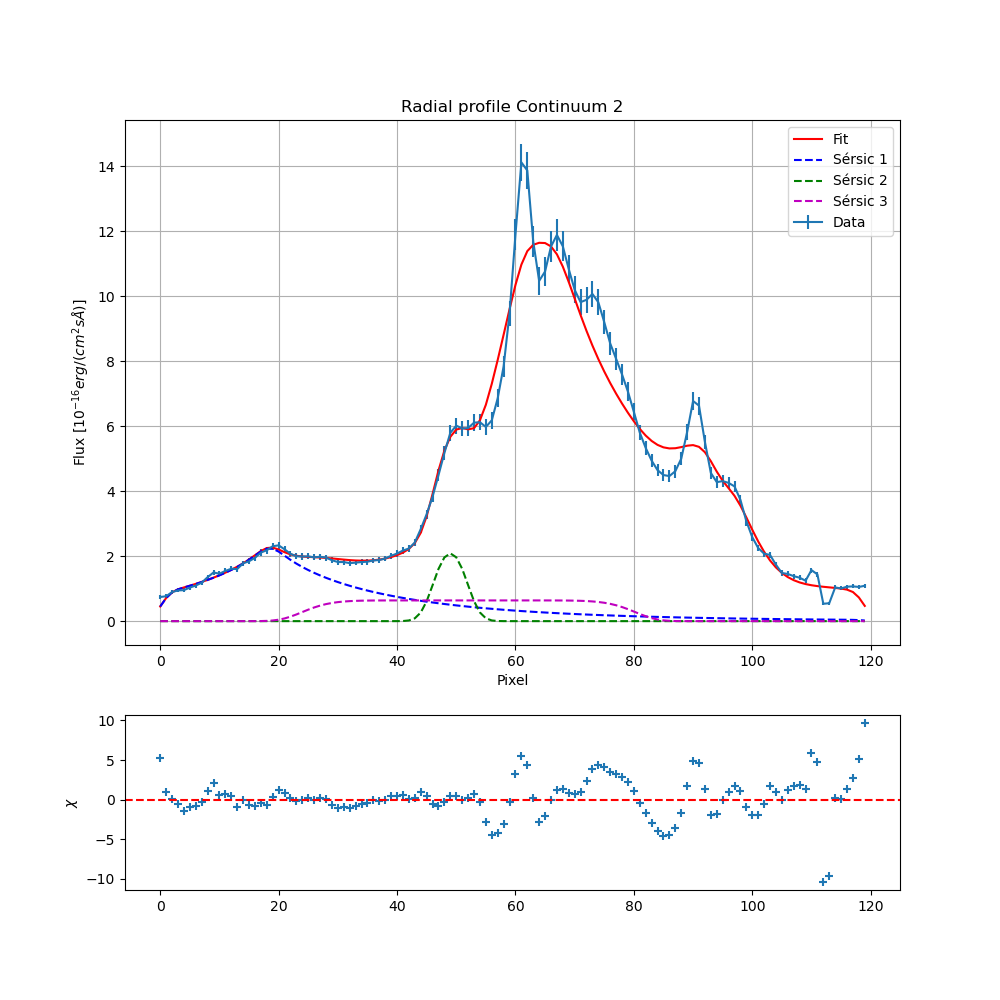

In [89]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigma_i, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

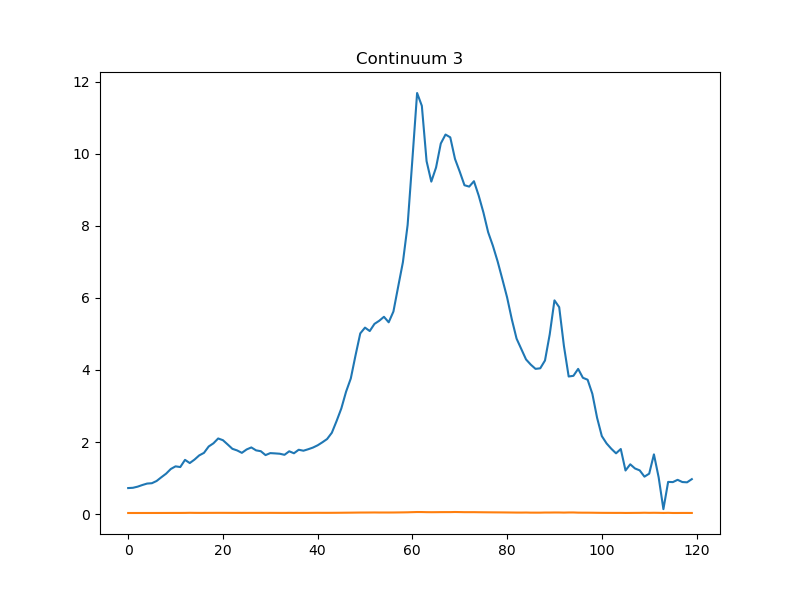

In [90]:
mask_continuum_3 = (wv > 6000)*(wv < 6500)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))

real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [91]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1841199.3765830528
differential_evolution step 2: f(x)= 1066547.968464096
differential_evolution step 3: f(x)= 1066547.968464096
differential_evolution step 4: f(x)= 1066547.968464096
differential_evolution step 5: f(x)= 354713.076583975
differential_evolution step 6: f(x)= 205156.43872654915
differential_evolution step 7: f(x)= 205156.43872654915
differential_evolution step 8: f(x)= 186352.58817757788
differential_evolution step 9: f(x)= 56497.65173922537
differential_evolution step 10: f(x)= 56497.65173922537
differential_evolution step 11: f(x)= 56497.65173922537
differential_evolution step 12: f(x)= 56497.65173922537
differential_evolution step 13: f(x)= 51592.43350647282
differential_evolution step 14: f(x)= 51592.43350647282
differential_evolution step 15: f(x)= 51592.43350647282
differential_evolution step 16: f(x)= 51592.43350647282
differential_evolution step 17: f(x)= 51592.43350647282
differential_evolution step 18: f(x)= 51592.4335064728

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_4404\3366555606.py:9: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=0.7249, r_e=14.8639, n=0.6694, x_0=18.5132
Sérsic 2: I_e=0.1422, r_e=2.2930, n=1.9403, x_0=48.9545
Sérsic 3: I_e=0.9944, r_e=22.0028, n=0.1002, x_0=53.9037
Sérsic 4: I_e=3.3502, r_e=11.4539, n=0.3662, x_0=61.9898
Sérsic 5: I_e=2.6807, r_e=17.2590, n=0.1000, x_0=78.9922
Sérsic 6: I_e=0.8307, r_e=0.2763, n=3.3849, x_0=89.9965
Sérsic 7: I_e=0.9764, r_e=30.2595, n=0.1003, x_0=95.0829
Chi quadro minimo: 17.724402121715382
False


Sérsic 1: I_e=0.7249, r_e=14.8639, n=0.6694, x_0=18.5132
Sérsic 2: I_e=0.1422, r_e=2.2930, n=1.9403, x_0=48.9545
Sérsic 3: I_e=0.9944, r_e=22.0028, n=0.1002, x_0=53.9037
Sérsic 4: I_e=3.3502, r_e=11.4539, n=0.3662, x_0=61.9898
Sérsic 5: I_e=2.6807, r_e=17.2590, n=0.1000, x_0=78.9922
Sérsic 6: I_e=0.8307, r_e=0.2763, n=3.3849, x_0=89.9965
Sérsic 7: I_e=0.9764, r_e=30.2595, n=0.1003, x_0=95.0829


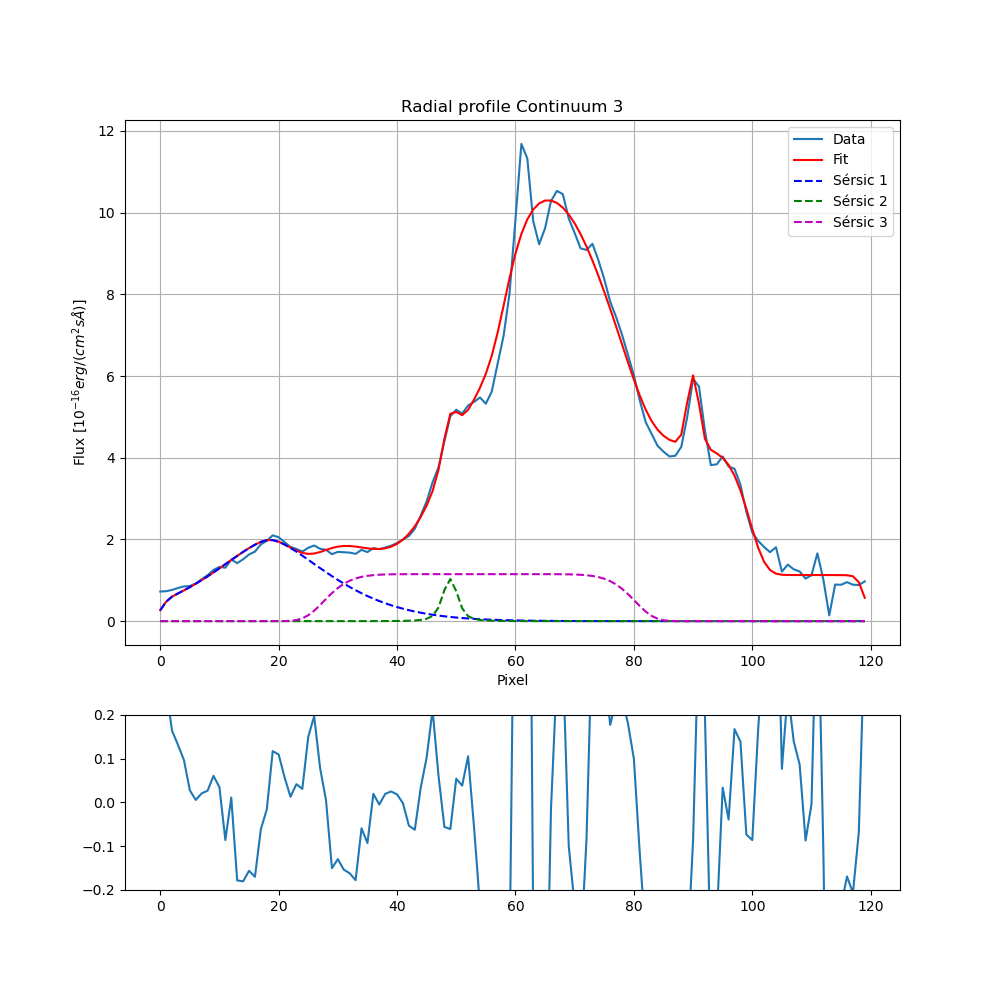

In [92]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [93]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3, bounds = bounds_list, maxfev = 10000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.4036, r_e=29.5223, n=0.9916, x_0=19.4721
Sérsic 2: I_e=0.2347, r_e=0.4252, n=2.3162, x_0=48.9807
Sérsic 3: I_e=0.8629, r_e=18.6592, n=0.1519, x_0=53.8724
Sérsic 4: I_e=3.5134, r_e=11.5037, n=0.2503, x_0=62.0000
Sérsic 5: I_e=2.8943, r_e=15.3362, n=0.1838, x_0=79.0000
Sérsic 6: I_e=1.9095, r_e=0.1389, n=3.4547, x_0=90.0000
Sérsic 7: I_e=0.8114, r_e=30.0089, n=0.1000, x_0=95.2378
[2.74733663e-01 1.76581532e+01 3.87346049e-01 1.50030954e+00
 4.65236939e+02 4.40918779e+02 4.13616040e+03 9.71191849e-01
 4.18024134e-01 1.62167135e+01 1.72045671e-01 2.05137374e+01
 8.49182097e-01 3.14927248e+00 1.87042680e-01 5.15378196e+00
 5.15348095e-01 4.79269920e+00 6.03473592e-02 6.72662366e+00
 8.94627373e+02 8.83471280e+00 1.96152877e+03 3.57134270e-01
 8.47890002e-01 3.26677896e+01 3.94030069e-01 2.94794272e+01]
8.898563804068857


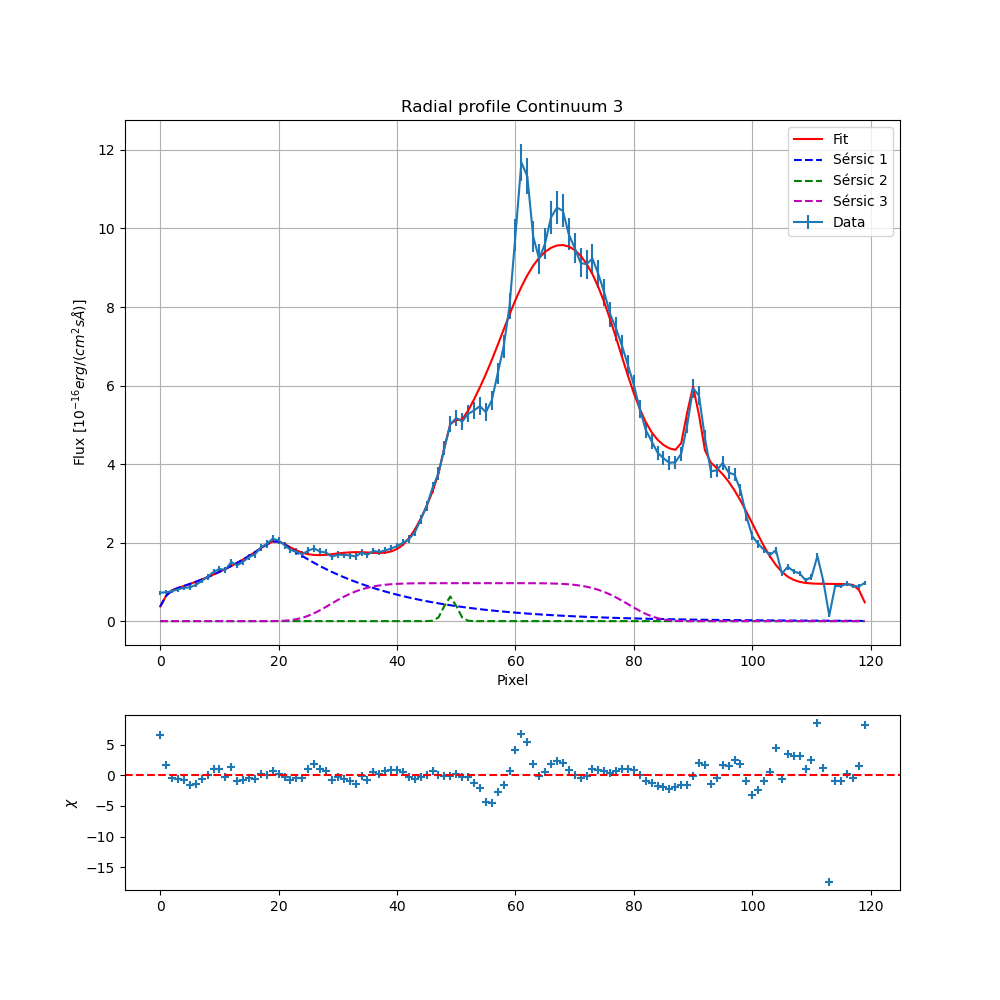

In [94]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

In [95]:
d1 = {'Name': ['Continuum 3'], 'Chi squared': chi2_continuum_3,
      'Dof': dof_continuum_3, 'Chi reduced': chi2_reduced_continuum_3}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_continuum_3.csv", index= False)

## Chi squared save

In [96]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII, 
           chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII, 
           dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII, 
           chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII', 'Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)